In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt

In [8]:
cyclone.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Year          16 non-null     int64
 1   Cyclone Name  16 non-null     str  
 2   Formed        16 non-null     str  
 3   Dissipated    16 non-null     str  
 4   Fatalities    16 non-null     str  
 5   Damage        16 non-null     str  
dtypes: int64(1), str(5)
memory usage: 900.0 bytes


In [9]:
import re

def extract_first_number(text):
    match = re.search(r'[\d,]+\.?\d*', text.replace(',', ''))
    if match:
        return float(match.group())
    return None

cyclone['Fatalities_clean'] = cyclone['Fatalities'].apply(extract_first_number)
cyclone[['Fatalities', 'Fatalities_clean']]

,Fatalities,Fatalities_clean
0,~15 (approx),15.0
1,204,204.0
2,118 (India+Sri Lanka),118.0
3,48,48.0
4,75 (India+Sri Lanka),75.0
5,~1-5 (minimal),1.0
6,18 in TN (47 India-wide incl AP),18.0
7,"245-318 (TN+Kerala, mostly fishermen)",245.0
8,52-63 (varies by source),52.0
9,14,14.0


In [10]:
def extract_damage_millions(text):
    text = text.lower()
    match = re.search(r'[\d,]+\.?\d*', text.replace(',', ''))
    if not match:
        return None
    value = float(match.group())
    if 'billion' in text:
        value = value * 1000
    return value  # returns value in millions USD

cyclone['Damage_millions_clean'] = cyclone['Damage'].apply(extract_damage_millions)
cyclone[['Damage', 'Damage_millions_clean']]

,Damage,Damage_millions_clean
0,Not well documented,NaN
1,$800 million,800.0
2,$1.73 billion,1730.0
3,~$1 billion (reports range $235M-$1B),1000.0
4,$56.7 million (approx),56.7
5,Minimal (data limited),NaN
6,$3.38 billion,3380.0
7,$920 million (approx),920.0
8,$775 million-$1 billion,775000.0
9,$600 million (approx),600.0


In [11]:
def extract_damage_millions(text):
    text = text.lower()
    match = re.search(r'([\d,]+\.?\d*)\s*(million|billion)?', text.replace(',', ''))
    if not match or not match.group(1):
        return None
    value = float(match.group(1))
    unit = match.group(2)
    if unit == 'billion':
        value = value * 1000
    return value

cyclone['Damage_millions_clean'] = cyclone['Damage'].apply(extract_damage_millions)
cyclone[['Damage', 'Damage_millions_clean']]

,Damage,Damage_millions_clean
0,Not well documented,NaN
1,$800 million,800.0
2,$1.73 billion,1730.0
3,~$1 billion (reports range $235M-$1B),1000.0
4,$56.7 million (approx),56.7
5,Minimal (data limited),NaN
6,$3.38 billion,3380.0
7,$920 million (approx),920.0
8,$775 million-$1 billion,775.0
9,$600 million (approx),600.0


In [12]:
cyclone.dtypes

Year                       int64
Cyclone Name                 str
Formed                       str
Dissipated                   str
Fatalities                   str
Damage                       str
Fatalities_clean         float64
Damage_millions_clean    float64
dtype: object

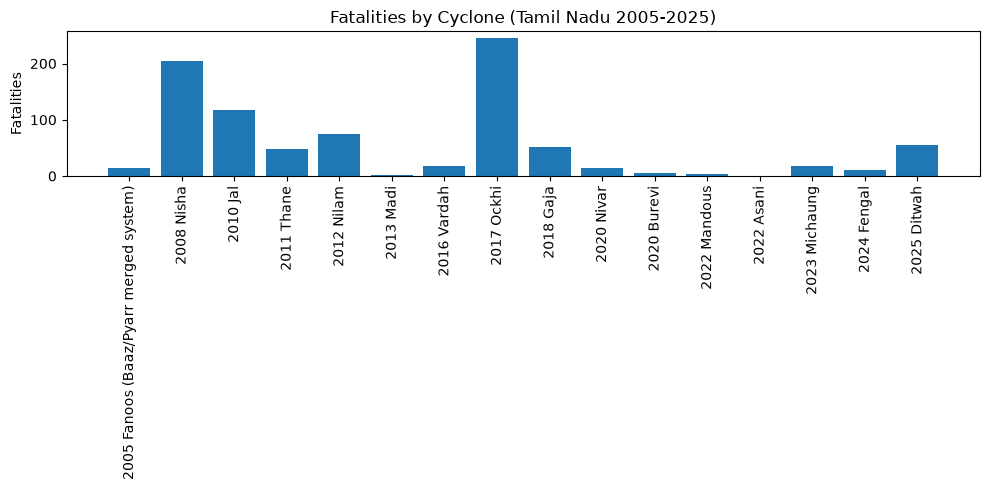

In [23]:
plt.figure(figsize=(10,5))
plt.bar(cyclone['Year'].astype(str) + " " + cyclone['Cyclone Name'], cyclone['Fatalities_clean'])
plt.xticks(rotation=90)
plt.ylabel('Fatalities')
plt.title('Fatalities by Cyclone (Tamil Nadu 2005-2025)')
plt.tight_layout()
plt.show()

In [24]:
print(cyclone.head())
print(cyclone.info())
print(cyclone['Fatalities_clean'].isnull().sum())

   Year                       Cyclone Name      Formed  Dissipated  \
0  2005  Fanoos (Baaz/Pyarr merged system)  2005-12-04  2005-12-08   
1  2008                              Nisha  2008-11-25  2008-11-29   
2  2010                                Jal  2010-11-01  2010-11-12   
3  2011                              Thane  2011-12-25  2011-12-30   
4  2012                              Nilam  2012-10-28  2012-11-01   

              Fatalities                                 Damage  \
0           ~15 (approx)                    Not well documented   
1                    204                           $800 million   
2  118 (India+Sri Lanka)                          $1.73 billion   
3                     48  ~$1 billion (reports range $235M-$1B)   
4   75 (India+Sri Lanka)                 $56.7 million (approx)   

   Fatalities_clean  Damage_millions_clean  
0              15.0                    NaN  
1             204.0                  800.0  
2             118.0                 1730.

In [28]:
print(cyclone[cyclone['Fatalities_clean'].isnull()])


    Year Cyclone Name      Formed  Dissipated     Fatalities  \
12  2022        Asani  2022-05-07  2022-05-12  Minimal in TN   

              Damage  Fatalities_clean  Damage_millions_clean  
12  Mainly AP impact               NaN                    NaN  


In [32]:
cyclone['Fatalities_clean'] = cyclone['Fatalities_clean'].fillna(0)
cyclone['Fatalities_clean']


0      15.0
1     204.0
2     118.0
3      48.0
4      75.0
5       1.0
6      18.0
7     245.0
8      52.0
9      14.0
10      5.0
11      4.0
12      0.0
13     17.0
14     10.0
15     56.0
Name: Fatalities_clean, dtype: float64

In [33]:
print("Total Fatalities:", cyclone['Fatalities_clean'].sum())
print("Average Fatalities per Cyclone:", cyclone['Fatalities_clean'].mean())
print("Max Fatalities:", cyclone['Fatalities_clean'].max())
print("Min Fatalities:", cyclone['Fatalities_clean'].min())

Total Fatalities: 882.0
Average Fatalities per Cyclone: 55.125
Max Fatalities: 245.0
Min Fatalities: 0.0


In [34]:
top5 = cyclone.sort_values(by='Fatalities_clean', ascending=False).head(5)
print(top5[['Year', 'Cyclone Name', 'Fatalities_clean']])

    Year Cyclone Name  Fatalities_clean
7   2017        Ockhi             245.0
1   2008        Nisha             204.0
2   2010          Jal             118.0
4   2012        Nilam              75.0
15  2025       Ditwah              56.0


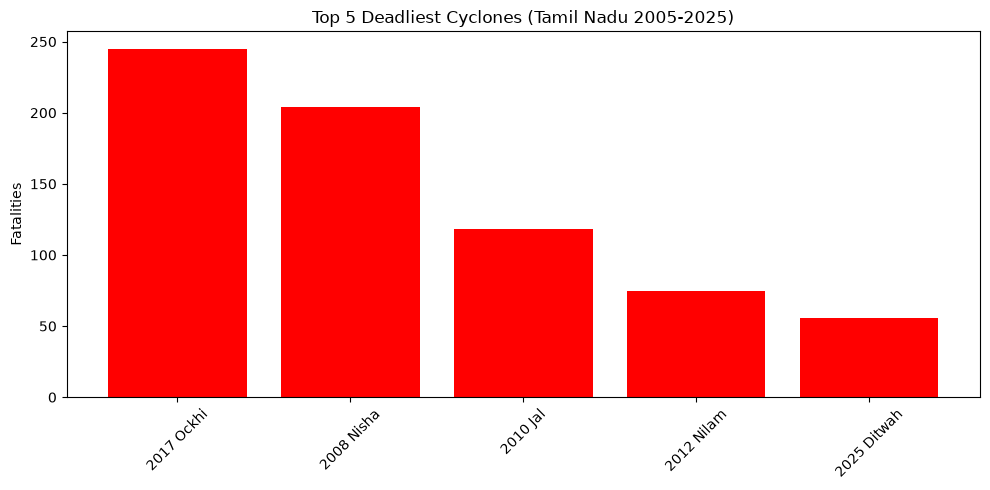

In [35]:
plt.figure(figsize=(10,5))
plt.bar(top5['Year'].astype(str) + " " + top5['Cyclone Name'], top5['Fatalities_clean'], color='red')
plt.xticks(rotation=45)
plt.ylabel('Fatalities')
plt.title('Top 5 Deadliest Cyclones (Tamil Nadu 2005-2025)')
plt.tight_layout()
plt.show()

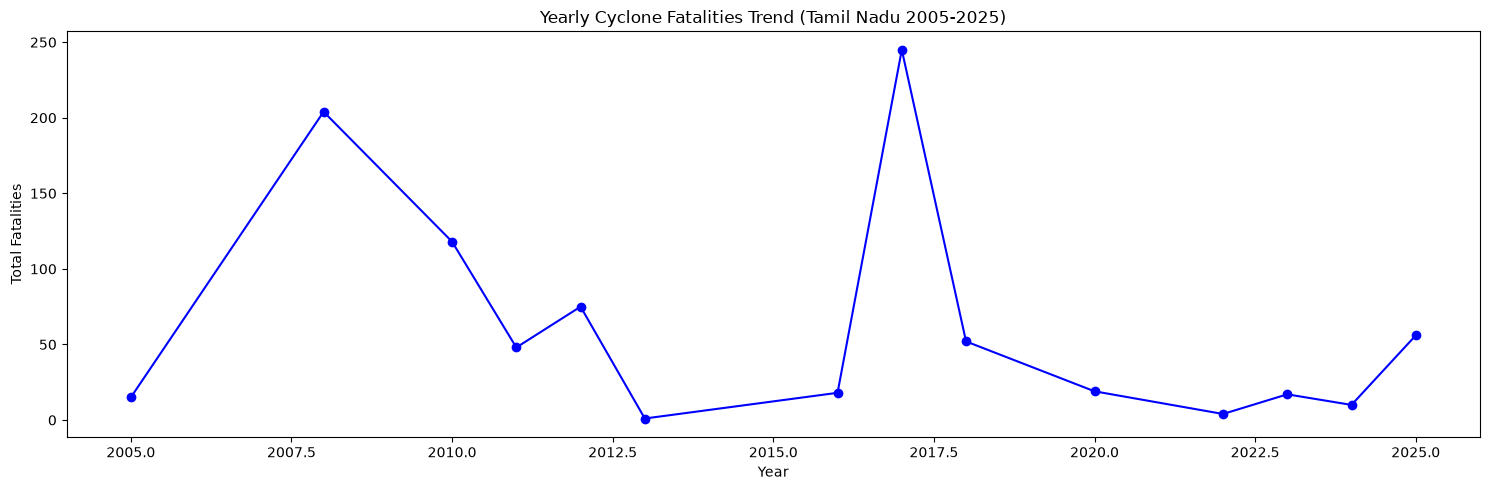

In [44]:
year_wise = cyclone.groupby('Year')['Fatalities_clean'].sum()

plt.figure(figsize=(15,5))
plt.plot(year_wise.index, year_wise.values, marker='o', color='blue')
plt.xlabel('Year')
plt.ylabel('Total Fatalities')
plt.title('Yearly Cyclone Fatalities Trend (Tamil Nadu 2005-2025)')
plt.tight_layout()
plt.show()

In [45]:
print(cyclone[['Year', 'Cyclone Name', 'Damage_millions_clean']].sort_values(by='Damage_millions_clean', ascending=False).head(5))

    Year Cyclone Name  Damage_millions_clean
6   2016       Vardah                 3380.0
2   2010          Jal                 1730.0
13  2023     Michaung                 1000.0
3   2011        Thane                 1000.0
7   2017        Ockhi                  920.0


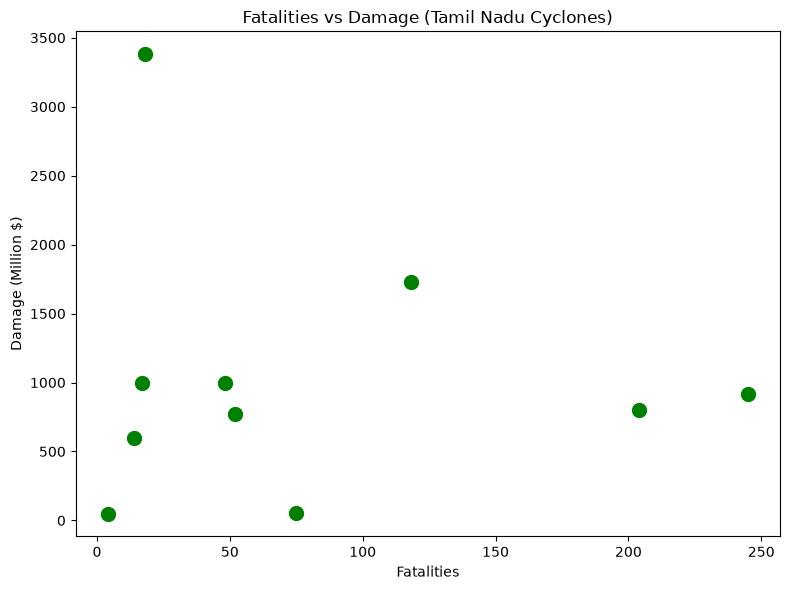

In [51]:
plt.figure(figsize=(8,6))
plt.scatter(cyclone['Fatalities_clean'], cyclone['Damage_millions_clean'], color='green', s=100)
plt.xlabel('Fatalities')
plt.ylabel('Damage (Million $)')
plt.title('Fatalities vs Damage (Tamil Nadu Cyclones)')
plt.tight_layout()
plt.show()

In [52]:
correlation = cyclone['Fatalities_clean'].corr(cyclone['Damage_millions_clean'])
print("Correlation between Fatalities and Damage:", correlation)

Correlation between Fatalities and Damage: -0.06626886240017259


In [53]:
print("===== CYCLONE ANALYSIS SUMMARY (Tamil Nadu 2005-2025) =====")
print(f"Total Cyclones Analyzed: {len(cyclone)}")
print(f"Total Fatalities: {int(cyclone['Fatalities_clean'].sum())}")
print(f"Average Fatalities per Cyclone: {cyclone['Fatalities_clean'].mean():.1f}")
print(f"Deadliest Cyclone: {cyclone.loc[cyclone['Fatalities_clean'].idxmax(), 'Cyclone Name']} ({int(cyclone['Fatalities_clean'].max())} deaths)")
print(f"Total Damage (available data): ${cyclone['Damage_millions_clean'].sum():.1f} million")
print(f"Costliest Cyclone: {cyclone.loc[cyclone['Damage_millions_clean'].idxmax(), 'Cyclone Name']} (${cyclone['Damage_millions_clean'].max():.1f} million)")
print(f"Fatalities-Damage Correlation: {correlation:.3f} (very weak/no relation)")

===== CYCLONE ANALYSIS SUMMARY (Tamil Nadu 2005-2025) =====
Total Cyclones Analyzed: 16
Total Fatalities: 882
Average Fatalities per Cyclone: 55.1
Deadliest Cyclone: Ockhi (245 deaths)
Total Damage (available data): $10311.7 million
Costliest Cyclone: Vardah ($3380.0 million)
Fatalities-Damage Correlation: -0.066 (very weak/no relation)
